XGBoost

=== XGBoost Inter-Zone Travel Time Prediction Model ===
Loading data...
✅ Data loaded successfully!
Feature matrix shape: (354528, 19)
Target shape: (354528,)

Data Overview:
- Features: 19
- Samples: 354528
- Target range: 1.0 - 120.0 minutes
- Mean travel time: 25.18 minutes
- Std travel time: 19.52 minutes

Missing values:
- Features: 0
- Target: 0

Feature columns:
 1. direct_distance_km
 2. bearing_sin
 3. bearing_cos
 4. hour_sin
 5. hour_cos
 6. dow_sin
 7. dow_cos
 8. is_weekend
 9. is_morning_rush
10. is_evening_rush
11. is_rush_hour
12. time_period_evening
13. time_period_evening_rush
14. time_period_late_night
15. time_period_midday
16. time_period_morning_rush
17. origin_zone_encoded
18. destination_zone_encoded
19. route_pair_id

Splitting data...
Train set: 226897 samples
Validation set: 56725 samples
Test set: 70906 samples

=== Training Initial XGBoost Model ===

XGBoost Base Performance:
  MAE:  7.434 minutes
  RMSE: 11.318 minutes
  R²:   0.6633
  MAPE: 35.63%

=== Hy

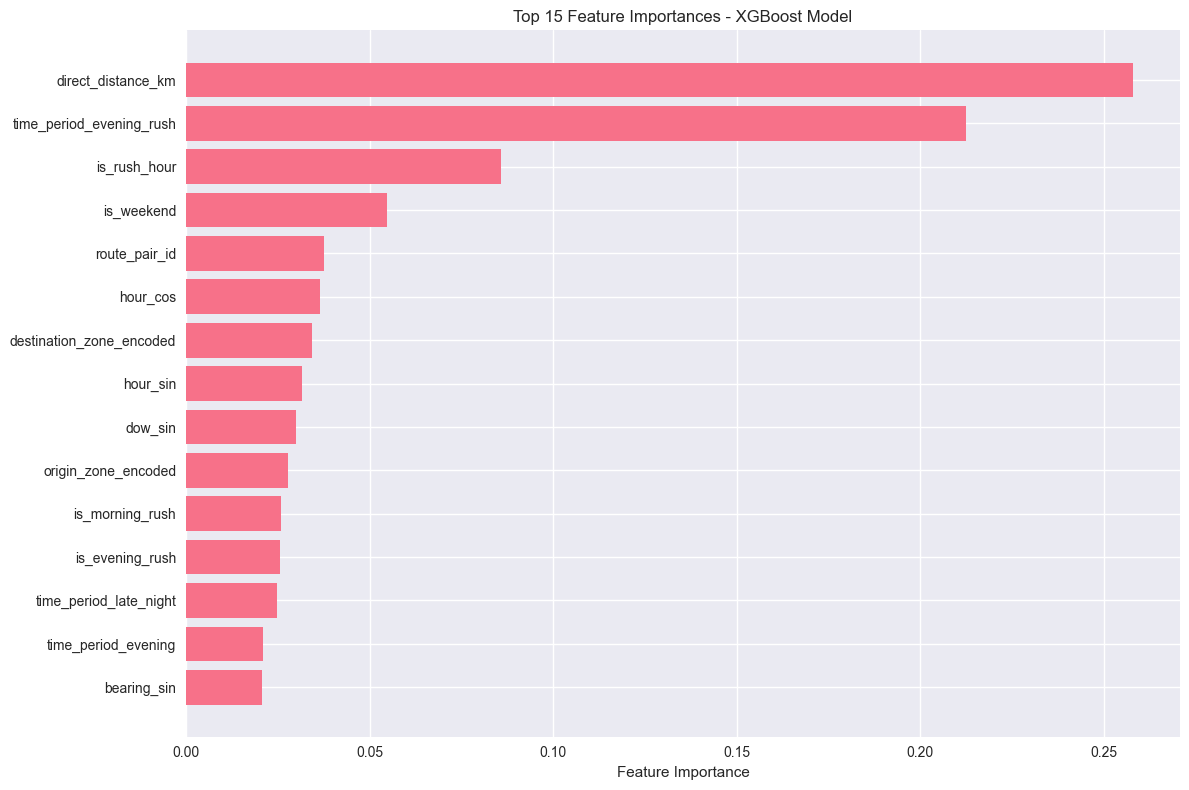


=== Final Test Set Evaluation ===

Final Model (Test Set) Performance:
  MAE:  7.238 minutes
  RMSE: 11.215 minutes
  R²:   0.6747
  MAPE: 34.24%


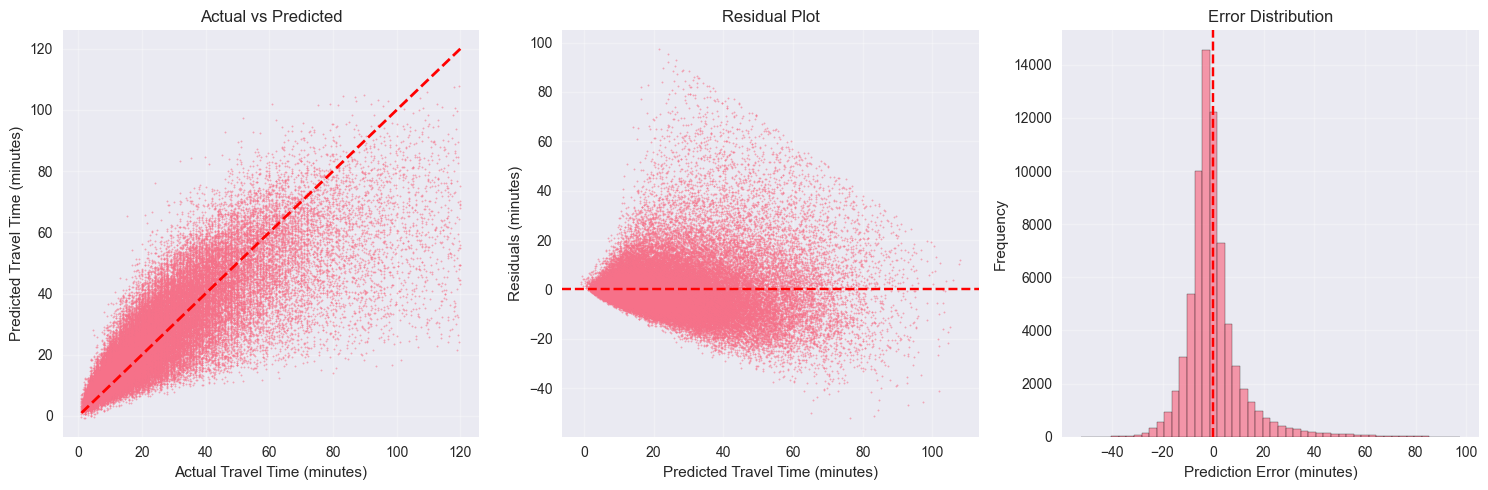


=== Performance Analysis by Segments ===
Performance by travel time ranges:
  (0, 5]: MAE = 3.23 min (n=3143)
  (5, 10]: MAE = 3.66 min (n=11394)
  (10, 20]: MAE = 4.64 min (n=22339)
  (20, 30]: MAE = 6.65 min (n=13751)
  (30, 60]: MAE = 9.65 min (n=15567)
  (60, 120]: MAE = 24.65 min (n=4712)

=== Cross-Validation Results ===
CV MAE Scores: [7.23318965 7.24628775 7.31980371 7.24935249 7.25923457]
CV MAE Mean: 7.262 ± 0.030

=== Saving Model and Artifacts ===
✅ Model saved as 'xgboost_inter_zone_model.pkl'
✅ Feature names saved as 'model_feature_names.pkl'
✅ Model metadata saved as 'model_metadata.json'

=== Training Complete! ===
Final Model Performance:
  Test MAE: 7.238 minutes
  Test RMSE: 11.215 minutes
  Test R²: 0.6747
  CV MAE: 7.262 ± 0.030

Files saved:
  - xgboost_inter_zone_model.pkl
  - model_feature_names.pkl
  - model_metadata.json
  - feature_importance.png
  - model_evaluation_plots.png

Model is ready for deployment! 🚀


In [1]:
# XGBoost Training Script for Inter-Zone Empty Travel Time Prediction
# Run this in your train_model notebook

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=== XGBoost Inter-Zone Travel Time Prediction Model ===")

# Load the prepared data
print("Loading data...")
try:
    X = pd.read_csv('X_features_inter_zone.csv')
    y = pd.read_csv('y_target_inter_zone.csv').squeeze()  # Convert to Series
    full_data = pd.read_csv('empty_trips_full_data.csv')
    print(f"✅ Data loaded successfully!")
    print(f"Feature matrix shape: {X.shape}")
    print(f"Target shape: {y.shape}")
except FileNotFoundError as e:
    print(f"❌ Error loading data: {e}")
    print("Make sure you've run the data preparation script first!")
    exit()

# Data validation
print(f"\nData Overview:")
print(f"- Features: {X.shape[1]}")
print(f"- Samples: {X.shape[0]}")
print(f"- Target range: {y.min():.1f} - {y.max():.1f} minutes")
print(f"- Mean travel time: {y.mean():.2f} minutes")
print(f"- Std travel time: {y.std():.2f} minutes")

# Check for missing values
print(f"\nMissing values:")
print(f"- Features: {X.isnull().sum().sum()}")
print(f"- Target: {y.isnull().sum()}")

# Remove any rows with missing values
if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("Cleaning missing values...")
    valid_idx = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[valid_idx].reset_index(drop=True)
    y = y[valid_idx].reset_index(drop=True)
    print(f"After cleaning: {X.shape[0]} samples")

# Feature analysis
print(f"\nFeature columns:")
for i, col in enumerate(X.columns):
    print(f"{i+1:2d}. {col}")

# Split data - using time-based split for better validation
print(f"\nSplitting data...")

# Sort by time if we have time info, otherwise random split
if 'route_pair_id' in X.columns:
    # Stratified split by route pairs to ensure balanced representation
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=None
    )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples") 
print(f"Test set: {X_test.shape[0]} samples")

# Baseline model evaluation
def evaluate_model(y_true, y_pred, model_name="Model"):
    """Evaluate model performance with comprehensive metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{model_name} Performance:")
    print(f"  MAE:  {mae:.3f} minutes")
    print(f"  RMSE: {rmse:.3f} minutes")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {"mae": mae, "rmse": rmse, "r2": r2, "mape": mape}

# Initial XGBoost model with default parameters
print(f"\n=== Training Initial XGBoost Model ===")

# Basic XGBoost model
xgb_base = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_base.fit(X_train, y_train)
y_pred_base = xgb_base.predict(X_val)
base_metrics = evaluate_model(y_val, y_pred_base, "XGBoost Base")

# Hyperparameter tuning with GridSearch
print(f"\n=== Hyperparameter Tuning ===")

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [500, 800, 1000],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

# Reduced grid for faster training - you can expand this if you have time
param_grid_reduced = {
    'n_estimators': [800, 1000],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.9],
    'colsample_bytree': [0.9],
    'reg_alpha': [0.1],
    'reg_lambda': [1.5]
}

print("Starting GridSearchCV (this may take a while)...")

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=3)

xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_reduced,
    cv=3,  # Use regular CV instead of TimeSeriesSplit for simplicity
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"✅ Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

# Train final model with best parameters
print(f"\n=== Training Final Optimized Model ===")

best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_val)
best_metrics = evaluate_model(y_val, y_pred_best, "XGBoost Optimized")

# Feature importance analysis
print(f"\n=== Feature Importance Analysis ===")

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances - XGBoost Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Model evaluation on test set
print(f"\n=== Final Test Set Evaluation ===")
y_pred_test = best_xgb.predict(X_test)
test_metrics = evaluate_model(y_test, y_pred_test, "Final Model (Test Set)")

# Prediction analysis
plt.figure(figsize=(15, 5))

# Actual vs Predicted scatter plot
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_test, alpha=0.5, s=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Travel Time (minutes)')
plt.ylabel('Predicted Travel Time (minutes)')
plt.title('Actual vs Predicted')
plt.grid(True, alpha=0.3)

# Residuals plot
plt.subplot(1, 3, 2)
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, alpha=0.5, s=1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Travel Time (minutes)')
plt.ylabel('Residuals (minutes)')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

# Error distribution
plt.subplot(1, 3, 3)
plt.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Prediction Error (minutes)')
plt.ylabel('Frequency')
plt.title('Error Distribution')
plt.axvline(x=0, color='r', linestyle='--')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Performance by different segments
print(f"\n=== Performance Analysis by Segments ===")

# Add predictions to test data for analysis
test_analysis = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_test,
    'error': y_test - y_pred_test,
    'abs_error': np.abs(y_test - y_pred_test)
})

# Performance by travel time ranges
time_bins = [0, 5, 10, 20, 30, 60, 120]
test_analysis['time_range'] = pd.cut(test_analysis['actual'], bins=time_bins)

print("Performance by travel time ranges:")
for time_range in test_analysis['time_range'].cat.categories:
    mask = test_analysis['time_range'] == time_range
    if mask.sum() > 0:
        subset = test_analysis[mask]
        mae = subset['abs_error'].mean()
        count = len(subset)
        print(f"  {time_range}: MAE = {mae:.2f} min (n={count})")

# Cross-validation scores
print(f"\n=== Cross-Validation Results ===")
cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_scores_positive = -cv_scores
print(f"CV MAE Scores: {cv_scores_positive}")
print(f"CV MAE Mean: {cv_scores_positive.mean():.3f} ± {cv_scores_positive.std():.3f}")

# Save the trained model and encoders
print(f"\n=== Saving Model and Artifacts ===")

# Save model
joblib.dump(best_xgb, 'xgboost_inter_zone_model.pkl')
print("✅ Model saved as 'xgboost_inter_zone_model.pkl'")

# Save feature names
feature_names = list(X.columns)
joblib.dump(feature_names, 'model_feature_names.pkl')
print("✅ Feature names saved as 'model_feature_names.pkl'")

# Save model metadata
model_metadata = {
    'model_type': 'XGBoost Regressor',
    'best_params': grid_search.best_params_,
    'feature_count': len(feature_names),
    'training_samples': len(X_train),
    'test_mae': test_metrics['mae'],
    'test_rmse': test_metrics['rmse'],
    'test_r2': test_metrics['r2'],
    'cv_mae_mean': cv_scores_positive.mean(),
    'cv_mae_std': cv_scores_positive.std(),
    'feature_importance': feature_importance.to_dict('records')
}

import json
with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)
print("✅ Model metadata saved as 'model_metadata.json'")

# Create prediction function for easy inference
def predict_travel_time(origin_zone, dest_zone, hour, day_of_week, is_weekend=None, distance_km=None):
    """
    Simple prediction function for new data points
    This is a template - you'll need to implement proper feature engineering
    """
    print("Note: This is a template function. Implement proper feature engineering based on your features.")
    return None

print(f"\n=== Training Complete! ===")
print(f"Final Model Performance:")
print(f"  Test MAE: {test_metrics['mae']:.3f} minutes")
print(f"  Test RMSE: {test_metrics['rmse']:.3f} minutes") 
print(f"  Test R²: {test_metrics['r2']:.4f}")
print(f"  CV MAE: {cv_scores_positive.mean():.3f} ± {cv_scores_positive.std():.3f}")

print(f"\nFiles saved:")
print(f"  - xgboost_inter_zone_model.pkl")
print(f"  - model_feature_names.pkl") 
print(f"  - model_metadata.json")
print(f"  - feature_importance.png")
print(f"  - model_evaluation_plots.png")

print(f"\nModel is ready for deployment! 🚀")